# Fase 2-3: Obtención, gobierno e ingesta/auditoría de datos

## 2. Obtención y licencia

- **Fuente:** dataset compilado *gold-price-prediction-dataset.csv* (compilación pública de series de mercado; uso académico).
- **Método:** archivo CSV; contenido: 61 columnas (fecha + 60 variables).
- **Periodo:** 1901-06-30 -> 2025-09-14, frecuencia diaria.
- **Integridad:** el archivo en `data/raw/` es **inmutable** (nunca se modifica); los derivados van a `interim/` y `processed/`.
- **Licencia:** uso académico/educativo; sin datos personales. Ver `LICENSE`.

## 3. Ingesta y auditoría

### 3.1 Validación de esquema

- 45,368 filas x 61 columnas; `date` datetime64 única; 60 columnas float64.
- Sin duplicados de fecha.

### 3.2 Calidad básica

- **Cobertura desigual:** la mayoría de series empiezan a mediados del s. XX; `gold_spot` arranca en 1979-12-27.
- **Fines de semana:** 12,963 filas (28.6%) sin cotización de oro -> no son días de mercado.
- **Huecos largos** en exógenas (CPI, paro... ~31 días; `ovx_index` 961 días) -> gobernar con forward-fill y umbral de cobertura.

### 3.3 Riesgos iniciales detectados

| Riesgo | Detección | Mitigación |
|---|---|---|
| Ventana con cobertura insuficiente (1901-1979) | cobertura < 3% | recorte a 2000+ |
| Fines de semana sin cotización | 28.6% filas | filtrado (solo días hábiles) |
| Features macro con retraso de publicación | huecos de ~31 días | forward-fill (solo pasado) |
| Features casi vacías (CPI, M2, google_trends...) | < 5% cobertura | exclusión en config |
| Leakage por orden de filas | - | orden temporal estricto garantizado |

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))

Carga del dataset crudo (sin modificar).

`load_raw()` lee el CSV, ordena por fecha y devuelve un DataFrame. Nunca
escribe sobre `data/raw/` (inmutabilidad de los datos originales).

In [2]:
import pandas as pd
import numpy as np

from src.data.load_data import load_raw

df = load_raw()
print("Shape:", df.shape)
print("Fechas:", df["date"].min().date(), "->", df["date"].max().date())
print("Duplicados de fecha:", df["date"].duplicated().sum())
print("Columnas float64:", (df.dtypes == "float64").sum(),
      "| datetime:", (df.dtypes == "datetime64[us]").sum())

Shape: (45368, 61)
Fechas: 1901-06-30 -> 2025-09-14
Duplicados de fecha: 0
Columnas float64: 60 | datetime: 1


Auditoría de cobertura por columna.

Calculamos el porcentaje de valores no nulos de cada variable. Esto revela
qué series son utilizables en la ventana moderna y cuáles son demasiado
dispersas (CPI, PIB, M2, google_trends...) y deben excluirse.

In [3]:
nn = df.notna().mean()
print("Cobertura media global: {:.1%}".format(nn.mean()))
print("Columnas con cobertura <5%:", (nn < 0.05).sum())
print("Columnas con cobertura >=50%:", (nn >= 0.5).sum(), "de", len(nn))

# Las 10 columnas con menos cobertura
print("\nPeor cobertura:")
print(nn.sort_values().head(10).round(3).to_string())

Cobertura media global: 14.9%
Columnas con cobertura <5%: 22
Columnas con cobertura >=50%: 1 de 61

Peor cobertura:
us_fiscal_deficit             0.003
google_trends_gold_word       0.006
google_trends_gold_element    0.006
us_gdp                        0.007
us_retail_sales               0.009
export_price_index            0.009
copper_spot                   0.009
us10y_real                    0.012
fx_reserves_china             0.012
consumer_confidence           0.014


Cobertura de gold_spot y fin de semana.

El oro cotiza en días hábiles (COMEX/NYMEX). Las filas de fin de semana no
tienen cotización y deben eliminarse en la limpieza. Verificamos cuándo
empieza la serie de gold_spot y cuántas filas de fin de semana hay.

In [4]:
gs = df.dropna(subset=["gold_spot"])
print("gold_spot: desde", gs["date"].min().date(), "hasta", gs["date"].max().date(),
      "|", len(gs), "observaciones")

wk = df["date"].dt.dayofweek >= 5
print("Filas de fin de semana:", wk.sum(), f"({wk.mean():.1%})")

gold_spot: desde 1979-12-27 hasta 2025-09-12 | 11853 observaciones
Filas de fin de semana: 12963 (28.6%)


Huecos temporales por columna en la ventana 2000+.

Detectamos los mayores huecos (días sin dato) de cada serie. Esto informa
la estrategia de imputación: forward-fill (solo pasado) para series con
huecos de ~1 mes (macro) y exclusión para huecos de cientos de días.

In [5]:
sub = df[df["date"] >= "2000-01-01"]
gaps = {}
for c in sub.columns:
    if c == "date":
        continue
    s = sub[c].dropna()
    if len(s) > 1:
        gaps[c] = s.index.to_series().diff().max() or 0
top = pd.Series(gaps).sort_values(ascending=False).head(8)
print("Mayores huecos (días) en 2000+:")
print(top.to_string())

Mayores huecos (días) en 2000+:
ovx_index                   961.0
us_fiscal_deficit           366.0
us_gdp                       92.0
palladium_futures            73.0
us_cpi                       31.0
us_industrial_production     31.0
us10y_real                   31.0
copper_spot                  31.0


Visualización de la cobertura temporal (heatmap por década).

Cada celda muestra el % de datos disponibles de una variable en una década.
Se aprecia claramente que la información fiable empieza ~2000 y que muchas
series macro son muy recientes. Esto justifica la ventana de análisis.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\audit_coverage_heatmap.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/audit_coverage_heatmap.png')

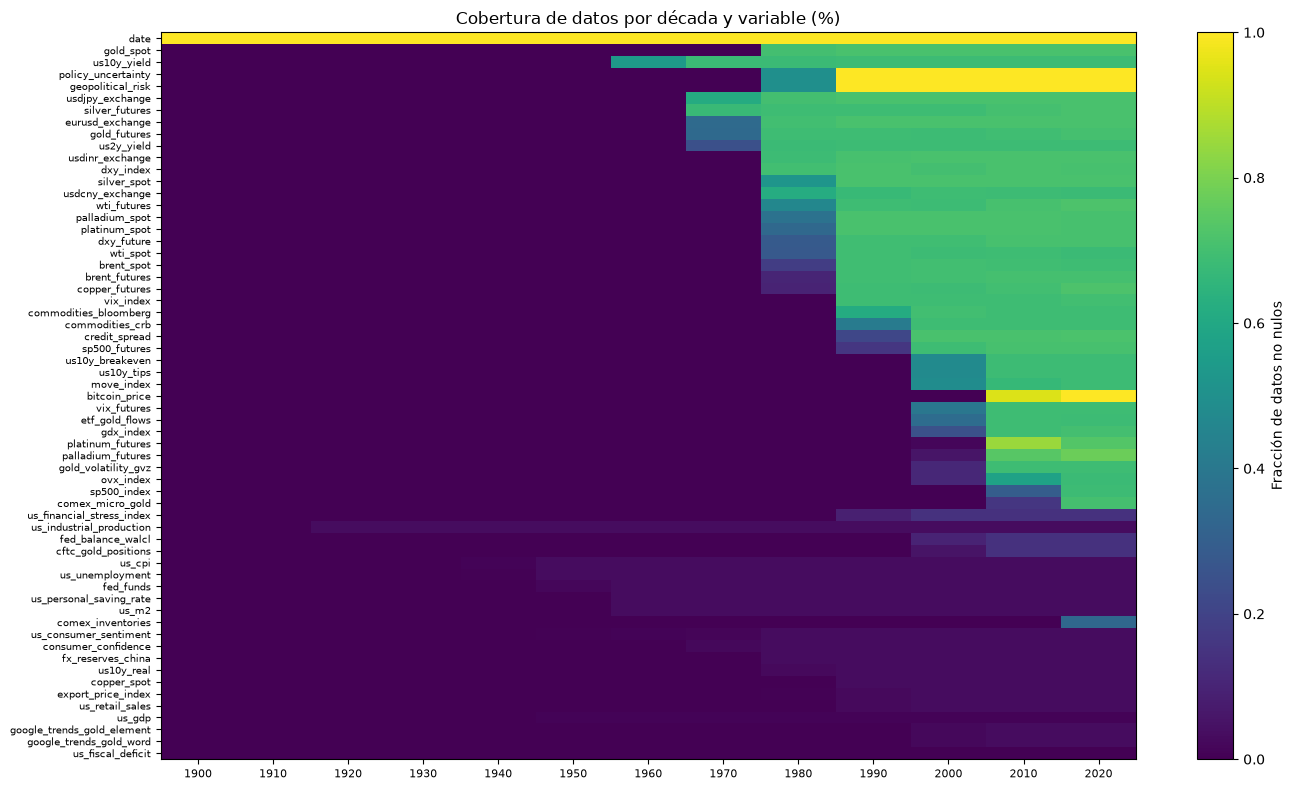

In [6]:
import matplotlib.pyplot as plt

df["decade"] = (df["date"].dt.year // 10) * 10
coverage = df.groupby("decade").apply(
    lambda g: g.notna().mean(), include_groups=False)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(coverage.T.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(len(coverage.columns)))
ax.set_yticklabels(coverage.columns, fontsize=7)
ax.set_xticks(range(len(coverage.index)))
ax.set_xticklabels(coverage.index, fontsize=8)
ax.set_title("Cobertura de datos por década y variable (%)")
fig.colorbar(im, label="Fracción de datos no nulos")
plt.tight_layout()

from src.utils import save_fig
save_fig(fig, "audit_coverage_heatmap.png")